In [1]:
# ============================================================
# NOTEBOOK 8
# ADVANCED ANN TRAINING AND EVALUATION
# Heart Disease Prediction Using Wearable Devices
# ============================================================

print("=" * 70)
print("ADVANCED ANN TRAINING")
print("=" * 70)

print("Purpose:")
print("Train a new ANN using the advanced feature-engineered dataset.")

print("\nBaseline ANN:")
print("Features : 15")
print("Accuracy: 73.48%")
print("ROC-AUC : 0.8027")

print("\nNew Experiment:")
print("Features : 24")
print("Accuracy: To be determined")
print("ROC-AUC : To be determined")

print("=" * 70)

ADVANCED ANN TRAINING
Purpose:
Train a new ANN using the advanced feature-engineered dataset.

Baseline ANN:
Features : 15
Accuracy: 73.48%
ROC-AUC : 0.8027

New Experiment:
Features : 24
Accuracy: To be determined
ROC-AUC : To be determined


In [2]:
# ============================================================
# CELL 2 - IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully.")

TensorFlow version: 2.21.0
Libraries imported successfully.


In [3]:
# ============================================================
# CELL 3 - LOAD ADVANCED FEATURE DATASET
# ============================================================

input_path = "../data/processed_data/advanced_feature_engineered_dataset.csv"

df = pd.read_csv(input_path)

print("=" * 70)
print("ADVANCED DATASET LOADED")
print("=" * 70)

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

display(df.head())

ADVANCED DATASET LOADED
Rows    : 68036
Columns : 24


,age,gender,height,weight,Systolic_BP,Diastolic_BP,cholesterol,Glucose,smoke,Alcohol,...,MAP,BMI_Category_Advanced,BP_Ratio_Advanced,Age_Years_Advanced,Age_Squared_Advanced,Age_x_SystolicBP,Age_x_Cholesterol,BMI_x_Cholesterol,SystolicBP_x_Cholesterol,BMI_x_Age
0,50.4,2,168,62.0,110,80,1,1,0,0,...,90.00,1.0,1.375000,50.4,2540.16,5544.0,50.4,21.967120,110,1107.142857
1,55.4,1,156,85.0,140,90,3,1,0,0,...,106.67,3.0,1.555556,55.4,3069.16,7756.0,166.2,104.783037,420,1934.993425
2,51.7,1,165,64.0,130,70,3,1,0,0,...,90.00,1.0,1.857143,51.7,2672.89,6721.0,155.1,70.523416,390,1215.353535
3,48.3,2,169,82.0,150,100,1,1,0,0,...,116.67,2.0,1.500000,48.3,2332.89,7245.0,48.3,28.710479,150,1386.716151
4,47.9,1,156,56.0,100,60,1,1,0,0,...,73.33,1.0,1.666667,47.9,2294.41,4790.0,47.9,23.011177,100,1102.235371


In [4]:
# ============================================================
# CELL 4 - DISPLAY DATASET COLUMNS
# ============================================================

print("=" * 70)
print("DATASET COLUMNS")
print("=" * 70)

for i, column in enumerate(df.columns, start=1):
    print(f"{i:2}. {column}")

DATASET COLUMNS
 1. age
 2. gender
 3. height
 4. weight
 5. Systolic_BP
 6. Diastolic_BP
 7. cholesterol
 8. Glucose
 9. smoke
10. Alcohol
11. Physical_Activity
12. Heart_Disease
13. BMI
14. Pulse_Pressure
15. MAP
16. BMI_Category_Advanced
17. BP_Ratio_Advanced
18. Age_Years_Advanced
19. Age_Squared_Advanced
20. Age_x_SystolicBP
21. Age_x_Cholesterol
22. BMI_x_Cholesterol
23. SystolicBP_x_Cholesterol
24. BMI_x_Age


In [5]:
# ============================================================
# CELL 5 - SEPARATE FEATURES AND TARGET
# ============================================================

target_column = "Heart_Disease"

if target_column not in df.columns:
    raise ValueError(
        "Heart_Disease column was not found."
    )

X = df.drop(
    columns=[target_column]
)

y = df[target_column]

print("=" * 70)
print("FEATURE / TARGET SEPARATION")
print("=" * 70)

print("Feature shape :", X.shape)
print("Target shape  :", y.shape)

print("\nTarget distribution:")
display(y.value_counts())

print("\nTarget proportions:")
display(y.value_counts(normalize=True))

FEATURE / TARGET SEPARATION
Feature shape : (68036, 23)
Target shape  : (68036,)

Target distribution:


Heart_Disease
0    34491
1    33545
Name: count, dtype: int64


Target proportions:


Heart_Disease
0    0.506952
1    0.493048
Name: proportion, dtype: float64

In [6]:
# ============================================================
# CELL 6 - CHECK DATA TYPES
# ============================================================

print("=" * 70)
print("DATA TYPES")
print("=" * 70)

display(X.dtypes)

DATA TYPES


age                         float64
gender                        int64
height                        int64
weight                      float64
Systolic_BP                   int64
Diastolic_BP                  int64
cholesterol                   int64
Glucose                       int64
smoke                         int64
Alcohol                       int64
Physical_Activity             int64
BMI                         float64
Pulse_Pressure                int64
MAP                         float64
BMI_Category_Advanced       float64
BP_Ratio_Advanced           float64
Age_Years_Advanced          float64
Age_Squared_Advanced        float64
Age_x_SystolicBP            float64
Age_x_Cholesterol           float64
BMI_x_Cholesterol           float64
SystolicBP_x_Cholesterol      int64
BMI_x_Age                   float64
dtype: object

In [7]:
# ============================================================
# CELL 7 - HANDLE MISSING AND INFINITE VALUES
# ============================================================

# Replace infinity with NaN
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

# Fill numerical missing values with median
for column in X.columns:

    if X[column].isnull().sum() > 0:

        X[column] = X[column].fillna(
            X[column].median()
        )

print("=" * 70)
print("DATA CLEANING")
print("=" * 70)

print("Missing values :", X.isnull().sum().sum())

print(
    "Infinite values:",
    np.isinf(X.select_dtypes(include=np.number)).sum().sum()
)

DATA CLEANING
Missing values : 0
Infinite values: 0


In [8]:
# ============================================================
# CELL 8 - TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

print("\nTraining Features:", X_train.shape[1])
print("Testing Features :", X_test.shape[1])

TRAIN / TEST SPLIT
Training Samples : 54428
Testing Samples  : 13608

Training Features: 23
Testing Features : 23


In [9]:
# ============================================================
# CELL 9 - FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("=" * 70)
print("FEATURE SCALING COMPLETED")
print("=" * 70)

print("Training shape:", X_train_scaled.shape)
print("Testing shape :", X_test_scaled.shape)

FEATURE SCALING COMPLETED
Training shape: (54428, 23)
Testing shape : (13608, 23)


In [10]:
# ============================================================
# CELL 10 - BUILD ADVANCED ANN
# ============================================================

model = Sequential([
    
    Input(
        shape=(X_train_scaled.shape[1],)
    ),

    Dense(
        128,
        activation="relu"
    ),

    BatchNormalization(),

    Dropout(0.30),

    Dense(
        64,
        activation="relu"
    ),

    BatchNormalization(),

    Dropout(0.25),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,721 (57.50 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [11]:
# ============================================================
# CELL 11 - COMPILE ANN
# ============================================================

model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy"
    ]
)

print("ANN compiled successfully.")

ANN compiled successfully.


In [12]:
# ============================================================
# CELL 12 - TRAINING CALLBACKS
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

print("Callbacks created successfully.")

Callbacks created successfully.


In [13]:
# ============================================================
# CELL 13 - TRAIN ADVANCED ANN
# ============================================================

history = model.fit(
    X_train_scaled,
    y_train,

    validation_split=0.20,

    epochs=100,

    batch_size=64,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

print("\nTraining completed.")

Epoch 1/100
681/681 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7098 - loss: 0.5797 - val_accuracy: 0.7303 - val_loss: 0.5552 - learning_rate: 0.0010
Epoch 2/100
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7278 - loss: 0.5589 - val_accuracy: 0.7311 - val_loss: 0.5465 - learning_rate: 0.0010
Epoch 3/100
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7261 - loss: 0.5552 - val_accuracy: 0.7308 - val_loss: 0.5439 - learning_rate: 0.0010
Epoch 4/100
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7291 - loss: 0.5534 - val_accuracy: 0.7308 - val_loss: 0.5469 - learning_rate: 0.0010
Epoch 5/100
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7321 - loss: 0.5515 - val_accuracy: 0.7312 - val_loss: 0.5446 - learning_rate: 0.0010
Epoch 6/100
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7303 - loss: 0.5509 - val_accuracy: 0.7318 - val_loss: 0.5423 - learning_rate: 0.0010
Epoch 7/100
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7304 - loss: 0.

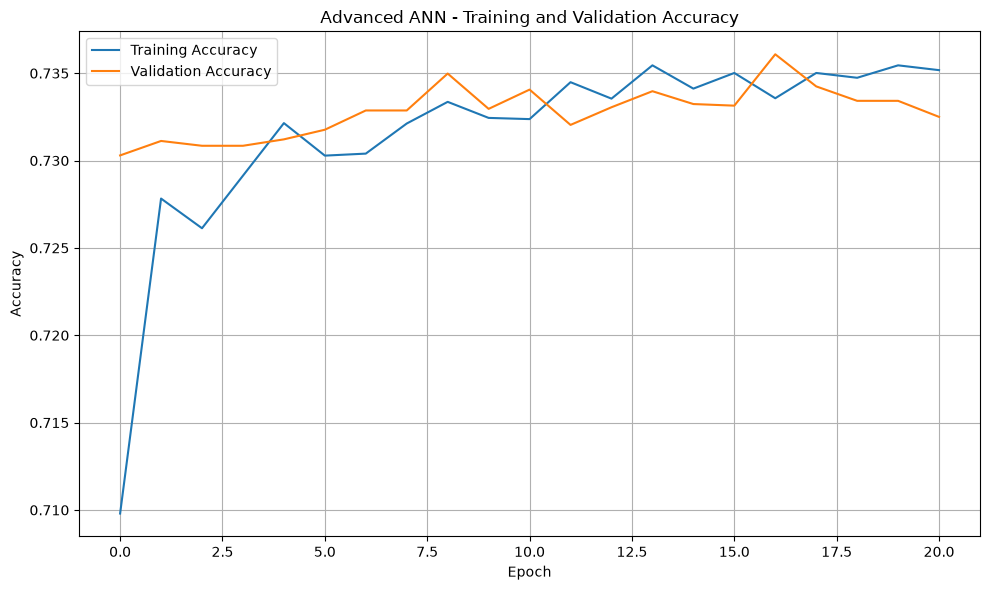

In [14]:
# ============================================================
# CELL 14 - TRAINING ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Advanced ANN - Training and Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

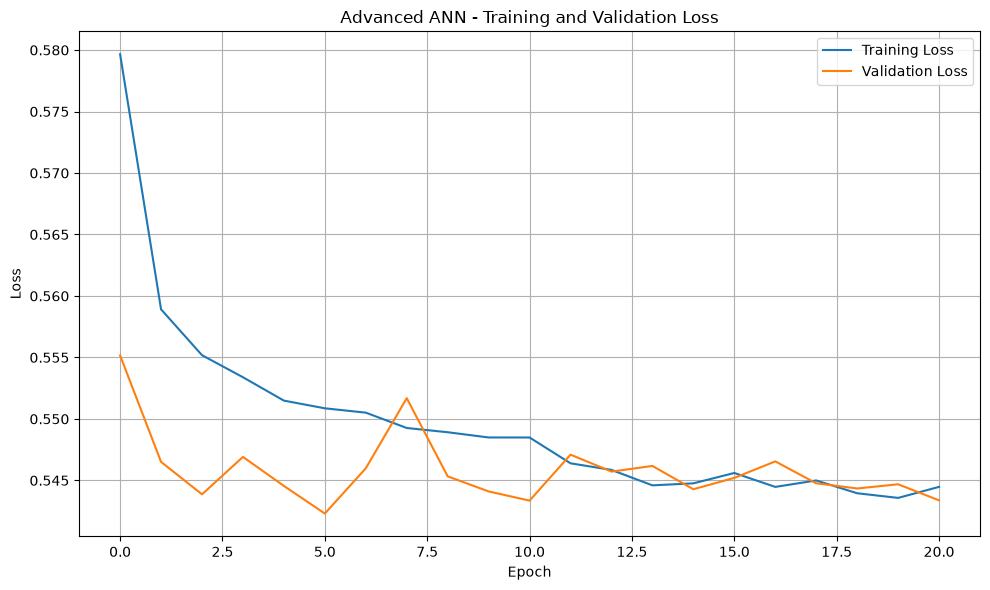

In [15]:
# ============================================================
# CELL 15 - TRAINING LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Advanced ANN - Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# CELL 16 - MAKE PREDICTIONS
# ============================================================

y_probability = model.predict(
    X_test_scaled,
    verbose=0
).ravel()

# Convert probabilities to 0/1
y_prediction = (
    y_probability >= 0.5
).astype(int)

print("Predictions generated successfully.")

print("\nFirst 10 probabilities:")
print(y_probability[:10])

print("\nFirst 10 predictions:")
print(y_prediction[:10])

Predictions generated successfully.

First 10 probabilities:
[0.10079651 0.25340912 0.83405066 0.30903387 0.36551964 0.07564592
 0.4002183  0.81081426 0.8122773  0.26396286]

First 10 predictions:
[0 0 1 0 0 0 0 1 1 0]


In [17]:
# ============================================================
# CELL 17 - MODEL PERFORMANCE
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_prediction
)

precision = precision_score(
    y_test,
    y_prediction
)

recall = recall_score(
    y_test,
    y_prediction
)

f1 = f1_score(
    y_test,
    y_prediction
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("=" * 70)
print("ADVANCED ANN RESULTS")
print("=" * 70)

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

ADVANCED ANN RESULTS
Accuracy  : 73.33%
Precision : 0.7549
Recall    : 0.6798
F1 Score  : 0.7154
ROC AUC   : 0.8018


CONFUSION MATRIX
[[5418 1481]
 [2148 4561]]


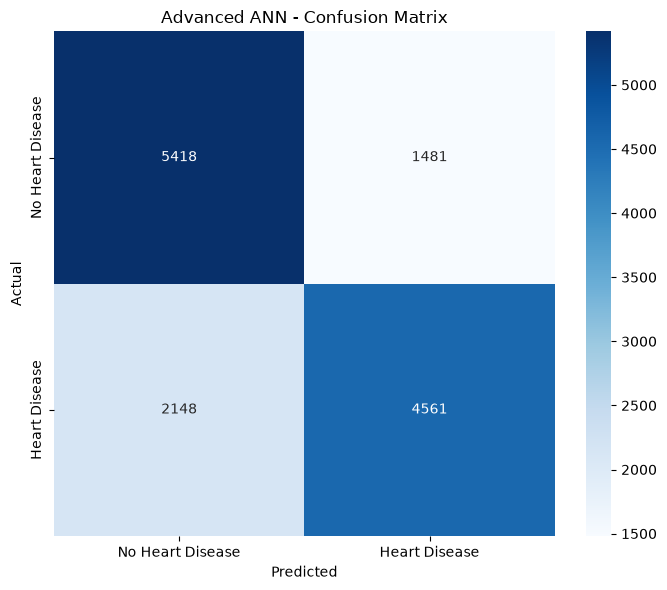

In [18]:
# ============================================================
# CELL 18 - CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_prediction
)

print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Heart Disease",
        "Heart Disease"
    ],
    yticklabels=[
        "No Heart Disease",
        "Heart Disease"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Advanced ANN - Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# CELL 19 - CLASSIFICATION REPORT
# ============================================================

print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_prediction,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)

CLASSIFICATION REPORT
                  precision    recall  f1-score   support

No Heart Disease       0.72      0.79      0.75      6899
   Heart Disease       0.75      0.68      0.72      6709

        accuracy                           0.73     13608
       macro avg       0.74      0.73      0.73     13608
    weighted avg       0.74      0.73      0.73     13608



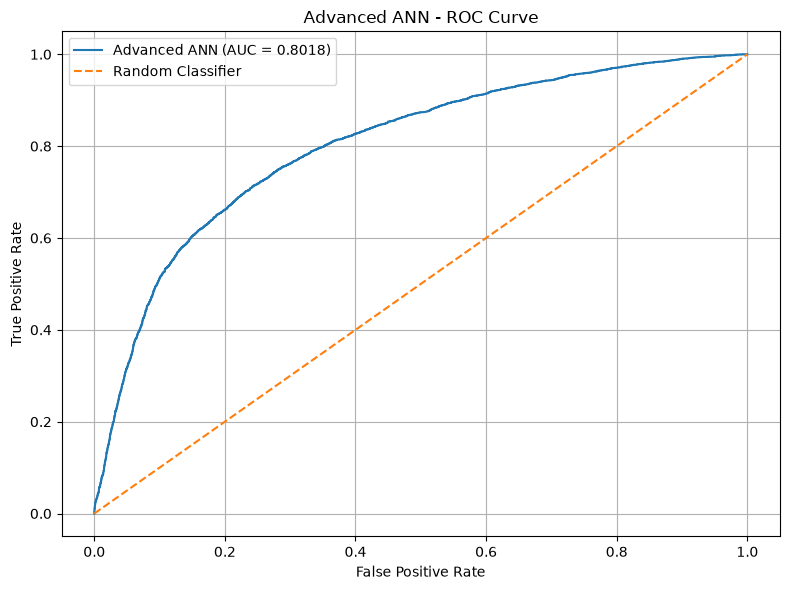

In [20]:
# ============================================================
# CELL 20 - ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Advanced ANN (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Advanced ANN - ROC Curve"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# CELL 21 - COMPARE ORIGINAL AND ADVANCED ANN
# ============================================================

original_accuracy = 73.48
original_precision = 0.7579
original_recall = 0.6789
original_f1 = 0.7163
original_roc_auc = 0.8027

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Original ANN": [
        original_accuracy,
        original_precision,
        original_recall,
        original_f1,
        original_roc_auc
    ],

    "Advanced ANN": [
        accuracy * 100,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

print("=" * 70)
print("ORIGINAL ANN vs ADVANCED ANN")
print("=" * 70)

display(comparison)

ORIGINAL ANN vs ADVANCED ANN


,Metric,Original ANN,Advanced ANN
0,Accuracy,73.4800,73.331864
1,Precision,0.7579,0.754882
2,Recall,0.6789,0.679833
3,F1 Score,0.7163,0.715395
4,ROC AUC,0.8027,0.801812


In [22]:
# ============================================================
# CELL 22 - CALCULATE IMPROVEMENT
# ============================================================

accuracy_improvement = (
    (accuracy * 100) -
    original_accuracy
)

roc_auc_improvement = (
    roc_auc -
    original_roc_auc
)

print("=" * 70)
print("IMPROVEMENT ANALYSIS")
print("=" * 70)

print(
    f"Accuracy improvement : "
    f"{accuracy_improvement:+.2f} percentage points"
)

print(
    f"ROC-AUC improvement  : "
    f"{roc_auc_improvement:+.4f}"
)

print("\nBaseline Accuracy :", f"{original_accuracy:.2f}%")
print(
    "Advanced Accuracy:",
    f"{accuracy * 100:.2f}%"
)

IMPROVEMENT ANALYSIS
Accuracy improvement : -0.15 percentage points
ROC-AUC improvement  : -0.0009

Baseline Accuracy : 73.48%
Advanced Accuracy: 73.33%


In [23]:
# ============================================================
# CELL 23 - SAVE ADVANCED ANN MODEL
# ============================================================

model_folder = "../models"

os.makedirs(
    model_folder,
    exist_ok=True
)

model_path = (
    model_folder +
    "/advanced_ann_model.keras"
)

model.save(
    model_path
)

print("=" * 70)
print("ADVANCED ANN MODEL SAVED")
print("=" * 70)

print("Model path:")
print(model_path)

ADVANCED ANN MODEL SAVED
Model path:
../models/advanced_ann_model.keras


In [24]:
# ============================================================
# CELL 24 - SAVE SCALER
# ============================================================

import joblib

scaler_path = (
    model_folder +
    "/advanced_ann_scaler.pkl"
)

joblib.dump(
    scaler,
    scaler_path
)

print("=" * 70)
print("SCALER SAVED")
print("=" * 70)

print("Scaler path:")
print(scaler_path)

SCALER SAVED
Scaler path:
../models/advanced_ann_scaler.pkl


In [25]:
# ============================================================
# CELL 25 - FINAL SUMMARY
# ============================================================

print("=" * 70)
print("FINAL ADVANCED ANN EXPERIMENT")
print("=" * 70)

print("Dataset rows       :", df.shape[0])
print("Input features     :", X.shape[1])
print("Training samples   :", X_train.shape[0])
print("Testing samples    :", X_test.shape[0])

print("\nOriginal ANN")
print("-----------------------------")
print("Accuracy :", f"{original_accuracy:.2f}%")
print("ROC AUC  :", f"{original_roc_auc:.4f}")

print("\nAdvanced ANN")
print("-----------------------------")
print("Accuracy :", f"{accuracy * 100:.2f}%")
print("Precision:", f"{precision:.4f}")
print("Recall   :", f"{recall:.4f}")
print("F1 Score :", f"{f1:.4f}")
print("ROC AUC  :", f"{roc_auc:.4f}")

print("\nImprovement")
print("-----------------------------")
print(
    f"Accuracy change : {accuracy_improvement:+.2f} percentage points"
)
print(
    f"ROC-AUC change  : {roc_auc_improvement:+.4f}"
)

print("=" * 70)

FINAL ADVANCED ANN EXPERIMENT
Dataset rows       : 68036
Input features     : 23
Training samples   : 54428
Testing samples    : 13608

Original ANN
-----------------------------
Accuracy : 73.48%
ROC AUC  : 0.8027

Advanced ANN
-----------------------------
Accuracy : 73.33%
Precision: 0.7549
Recall   : 0.6798
F1 Score : 0.7154
ROC AUC  : 0.8018

Improvement
-----------------------------
Accuracy change : -0.15 percentage points
ROC-AUC change  : -0.0009
